In [1]:
import pyro
import pyro.distributions as dist
import torch
import torch.nn.functional as F
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from pyro import poutine
from pyro.distributions import constraints
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import config_enumerate
import tqdm
import numpy as np
import seaborn
import matplotlib.pyplot as plt
import scvi
import scanpy as sc
import anndata
import pandas as pd
from collections import defaultdict
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import antipode

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU is available
Number of GPUs: 1
GPU Name: Tesla V100-SXM2-32GB


In [2]:
import torch
from torch.distributions import constraints
from torch.distributions.utils import (
    broadcast_all,
    lazy_property,
    logits_to_probs,
    probs_to_logits,
)
from torch.nn.functional import softplus

from pyro.distributions import LogNormal, TorchDistribution
from pyro.distributions.util import broadcast_shape

class DiscretePositiveZeroInflatedDistribution(TorchDistribution):
    """
    Generic Zero Inflated distribution.

    This can be used directly or can be used as a base class as e.g. for
    :class:`ZeroInflatedPoisson` and :class:`ZeroInflatedNegativeBinomial`.

    :param TorchDistribution base_dist: the base distribution.
    :param torch.Tensor gate: probability of extra zeros given via a Bernoulli distribution.
    :param torch.Tensor gate_logits: logits of extra zeros given via a Bernoulli distribution.
    """

    arg_constraints = {
        "gate": constraints.unit_interval,
        "gate_logits": constraints.real,
    }

    def __init__(self, base_dist, *, gate=None, gate_logits=None, validate_args=None):
        if (gate is None) == (gate_logits is None):
            raise ValueError(
                "Either `gate` or `gate_logits` must be specified, but not both."
            )
        if gate is not None:
            batch_shape = broadcast_shape(gate.shape, base_dist.batch_shape)
            self.gate = gate.expand(batch_shape)
        else:
            batch_shape = broadcast_shape(gate_logits.shape, base_dist.batch_shape)
            self.gate_logits = gate_logits.expand(batch_shape)
        if base_dist.event_shape:
            raise ValueError(
                "ZeroInflatedDistribution expected empty "
                "base_dist.event_shape but got {}".format(base_dist.event_shape)
            )

        self.base_dist = base_dist.expand(batch_shape)
        event_shape = torch.Size()

        super().__init__(batch_shape, event_shape, validate_args)

    @constraints.dependent_property
    def support(self):
        return self.base_dist.support

    @lazy_property
    def gate(self):
        return logits_to_probs(self.gate_logits, is_binary=True)

    @lazy_property
    def gate_logits(self):
        return probs_to_logits(self.gate, is_binary=True)

    def log_prob(self, value):
        if self._validate_args:
            self._validate_sample(value)

        if "gate" in self.__dict__:
            gate, value = broadcast_all(self.gate, value)
            log_prob = (-gate).log1p() + self.base_dist.log_prob(value)
            log_prob = torch.where(value == 0, gate.log(), log_prob)
        else:
            gate_logits, value = broadcast_all(self.gate_logits, value)
            log_prob_minus_log_gate = -gate_logits + self.base_dist.log_prob(value+1e-12)
            log_gate = -softplus(-gate_logits)
            log_prob = log_prob_minus_log_gate + log_gate
            #zero_log_prob = softplus(log_prob_minus_log_gate) + log_gate
            log_prob = torch.where(value == 0., log_gate, log_prob)#Replaced zero_log_prob with log_gate as log prob is nan at 0 for LN
        return log_prob

    def sample(self, sample_shape=torch.Size()):
        shape = self._extended_shape(sample_shape)
        with torch.no_grad():
            mask = torch.bernoulli(self.gate.expand(shape)).bool()
            samples = self.base_dist.expand(shape).sample()
            samples = torch.where(mask, samples.new_zeros(()), samples)
        return samples

    @lazy_property
    def mean(self):
        return (1 - self.gate) * self.base_dist.mean

    @lazy_property
    def variance(self):
        return (1 - self.gate) * (
            self.base_dist.mean**2 + self.base_dist.variance
        ) - (self.mean) ** 2

    def expand(self, batch_shape, _instance=None):
        new = self._get_checked_instance(type(self), _instance)
        batch_shape = torch.Size(batch_shape)
        gate = self.gate.expand(batch_shape) if "gate" in self.__dict__ else None
        gate_logits = (
            self.gate_logits.expand(batch_shape)
            if "gate_logits" in self.__dict__
            else None
        )
        base_dist = self.base_dist.expand(batch_shape)
        DiscretePositiveZeroInflatedDistribution.__init__(
            new, base_dist, gate=gate, gate_logits=gate_logits, validate_args=False
        )
        new._validate_args = self._validate_args
        return new


In [82]:
class ZeroInflatedLogNormal(DiscretePositiveZeroInflatedDistribution):
    """
    A Zero Inflated LogNormal distribution with left truncation.

    :param torch.Tensor loc: location parameter of the LogNormal distribution.
    :param torch.Tensor scale: scale parameter of the LogNormal distribution.
    :param torch.Tensor cutoff: cutoff value for truncation.
    :param torch.Tensor gate: probability of extra zeros.
    :param torch.Tensor gate_logits: logits of extra zeros.
    """

    arg_constraints = {
        "loc": constraints.real,
        "scale": constraints.positive,
        "gate": constraints.unit_interval,
        "gate_logits": constraints.real,
    }
    support = constraints.nonnegative

    def __init__(self, loc, scale, cutoff, *, gate=None, gate_logits=None, validate_args=None):
        
        # Calculate adjusted parameters
        gate_logits = -torch.logit(torch.clamp(torch.distributions.Normal(loc, scale).cdf(cutoff),min=1e-15,max=(1-1e-15)))
        #gate_logits = torch.clamp(gate_logits,min=-16., max=16.).float()
        base_dist = torch.distributions.LogNormal(loc=loc, scale=scale, validate_args=False)
        base_dist._validate_args = validate_args
        base_dist.support = constraints.nonnegative

        super().__init__(
            base_dist, gate=gate, gate_logits=gate_logits, validate_args=validate_args
        )

    @property
    def loc(self):
        return self.base_dist.loc

    @property
    def scale(self):
        return self.base_dist.scale


In [83]:
# Set random seed for reproducibility
pyro.set_rng_seed(0)

# Define constants
n_latent = 6
n_var = 250
n_components = 10
n_datapoints = 50000
locs_range = 2
batch_size = 32

In [84]:
grads=defaultdict(list)

import pyro
import pyro.ops.jit
from pyro.distributions.util import is_identically_zero
from pyro.infer.elbo import ELBO
from pyro.infer.enum import get_importance_trace
from pyro.infer.util import (
    MultiFrameTensor,
    get_plate_stacks,
    is_validation_enabled,
    torch_item,
)
from pyro.util import check_if_enumerated, warn_if_nan

class SafeSVI(pyro.infer.abstract_infer.TracePosterior):
    '''A version of pyro.infer.SVI that skips steps with loss more than X sigma from the running mean loss'''
    def __init__(
        self,
        model,
        guide,
        optim,
        loss,
        loss_and_grads=None,
        clip_std_multiplier=6.0,
        window_size=1000,  # Default window size of 300
        **kwargs
    ):
        super().__init__(**kwargs)
        self.model = model
        self.guide = guide
        self.optim = optim
        self.record = False
        self.clip_std_multiplier = clip_std_multiplier
        self.window_size = window_size
        self.losses = []  # Store recent losses to calculate running stats

        if not isinstance(optim, pyro.optim.PyroOptim):
            raise ValueError("Optimizer should be an instance of pyro.optim.PyroOptim class.")

        if isinstance(loss, ELBO):
            self.loss = loss.loss
            self.loss_and_grads = loss.loss_and_grads
        else:
            if loss_and_grads is None:
                def _loss_and_grads(*args, **kwargs):
                    loss_val = loss(*args, **kwargs)
                    if getattr(loss_val, "requires_grad", False):
                        loss_val.backward(retain_graph=True)
                    return loss_val
                self.loss_and_grads = _loss_and_grads
            else:
                self.loss_and_grads = loss_and_grads

    def _traces(self, *args, **kwargs):
        for i in range(self.num_samples):
            guide_trace = poutine.trace(self.guide).get_trace(*args, **kwargs)
            model_trace = poutine.trace(
                poutine.replay(self.model, trace=guide_trace)
            ).get_trace(*args, **kwargs)
            yield model_trace, 1.0

    def evaluate_loss(self, *args, **kwargs):
        with torch.no_grad():
            loss = self.loss(self.model, self.guide, *args, **kwargs)
            return torch_item(loss)

    def step(self, *args, **kwargs):
        # Compute loss and gradients
        with poutine.trace(param_only=True) as param_capture:
            loss = self.loss_and_grads(self.model, self.guide, *args, **kwargs)
    
        loss_val = torch_item(loss)
        self.losses.append(loss_val)
        # Keep only the last `window_size` losses
        if len(self.losses) > self.window_size:
            self.losses.pop(0)
        # Extract params early to ensure they are defined for later use
        params = set(site["value"].unconstrained() for site in param_capture.trace.nodes.values())
        
        # Calculate running mean and std only if we have enough data
        if len(self.losses) >= self.window_size:
            running_mean = np.mean(self.losses)
            running_std = np.std(self.losses)
            #print(loss, running_mean,running_std)
            if ((loss > running_mean-running_std*self.clip_std_multiplier) and (loss < running_mean+running_std*self.clip_std_multiplier)):
                # Perform optimization step
                self.optim(params)
            else:
                print('STEP SKIPPED')
        else:
            self.optim(params)
        
        if self.record:
            for name, value in pyro.get_param_store().named_parameters():
                grads[name].append(value.grad.detach().cpu().numpy())
        
        # Zero gradients
        pyro.infer.util.zero_grads(params)
    
        return loss_val

In [104]:
class ToyModel(torch.nn.Module):
    def __init__(self, n_latent=5, n_var=10, n_components=3):
        super(ToyModel, self).__init__()
        pyro.clear_param_store()
        self.n_latent = n_latent
        self.n_var = n_var
        self.n_components = n_components
        self.scale=1e-4
        # Assuming ZLEncoder and SimpleFFNN are defined elsewhere and imported
        self.encoder = antipode.train_utils.ZLEncoder(num_var=self.n_var, hidden_dims=[1000, 1000, 1000], outputs=[(self.n_latent, None), (self.n_latent, torch.nn.functional.softplus)])
        self.classifier = antipode.train_utils.SimpleFFNN(in_dim=self.n_latent, hidden_dims=[1000, 1000, 1000], out_dim=self.n_components)

    @config_enumerate
    def model(self, data=None):
        pyro.module("toy", self)
        device = data.device
        
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                l = data.sum(-1).unsqueeze(-1) + 1.
                
                # Ensure parameters are leaf tensors
                locs = pyro.param('locs', 0.1 * torch.randn(self.n_components, self.n_latent, device=device))
                scales = pyro.param('scales', torch.ones(self.n_components, self.n_latent, device=device), constraint=constraints.positive)
                transform_matrix = pyro.param('transform_matrix', 0.1 * torch.rand(self.n_latent, self.n_var, device=device))

                intercept = pyro.param('intercept', torch.zeros(self.n_components, self.n_var, device=device))
                total_counts = pyro.param('total_counts', 10 * torch.ones(self.n_var, device=device), constraint=constraints.positive)
                
                z = pyro.sample('z', dist.Categorical(logits=torch.ones(self.n_components, device=device)), infer={"enumerate": "parallel"})
                latent = pyro.sample('latent', dist.Normal(locs[z], scales[z]).to_event(1))
                out_mu = latent @ transform_matrix + intercept[z]
                #softmax_shift = pyro.param('softmax_shift', out_mu.detach().exp().sum(-1).mean().log())
                #logits = out_mu - total_counts.log() + l.log() - softmax_shift
                #logits = torch.nn.functional.log_softmax(out_mu,dim=-1) - total_counts.log() + l.log() #- softmax_shift
                #pyro.sample('obs', dist.NegativeBinomial(total_count=total_counts, logits=logits,validate_args=False).to_event(1), obs=data+1e-6)
                #b_dist = dist.Bernoulli(probs=1-((total_counts * torch.nn.functional.logsigmoid(-logits))).exp()).to_event(1)
                #b_out=pyro.sample("b",b_dist, obs=(data>0.).float())
                #pyro.sample('obs', dist.Normal(loc=logits,scale=total_counts,validate_args=False).to_event(1), obs=(data+1e-9).log())#Reverses the gradient trends, but doesn't reconstruct well
                norm_mu=torch.nn.functional.log_softmax(out_mu,dim=-1) + l.log()-(total_counts**2)/2
                pyro.sample('obs', ZeroInflatedLogNormal(loc=norm_mu,scale=total_counts,cutoff=data.new_zeros(1),validate_args=False).to_event(1), obs=data.float())
                #pyro.sample('obs', dist.LogNormal(loc=norm_mu,scale=total_counts,validate_args=False).to_event(1), obs=data.float()+1.)


    def guide(self, data=None):
        pyro.module("toy", self)
        device = data.device
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                locs_mu, locs_std = self.encoder(data)
                latent = pyro.sample('latent', dist.Normal(locs_mu, locs_std).to_event(1))
                weights_probs = pyro.sample('z', dist.Categorical(logits=self.classifier(latent)), infer={"enumerate": "parallel"})

In [105]:
# Generate synthetic data
def generate_synthetic_data(n_datapoints=5000,locs_range=2.):
    weights = torch.ones(n_components) / n_components
    locs = torch.randn(n_components, n_latent) * locs_range
    scales = torch.ones(n_components, n_latent) * 0.5
    transform_matrix = 1.*torch.randn(n_latent, n_var)
    intercept = 4*torch.rand(n_components, n_var)-2.
    overall_intercept = 16*torch.rand(n_var)-8.
    data = []
    true_clusters=[]
    true_latent=[]
    for _ in range(n_datapoints):
        l = 7 + 2*torch.rand(1)
        z = torch.multinomial(weights, 1).item()
        true_clusters.append(z)
        latent = torch.normal(locs[z], scales[z])
        true_latent.append(latent)
        out_mu = latent @ transform_matrix + intercept[z] + overall_intercept
        total_counts = torch.tensor(25.0)
        logits = (torch.softmax(out_mu,dim=-1)*l.exp()).log() - torch.log(total_counts) 
        counts = dist.NegativeBinomial(total_counts, logits=logits).sample()
        data.append(counts)
    
    return torch.stack(data),{'latent':true_latent,'clusters':true_clusters,'weights':weights,'locs':locs,'scales':scales,'intercept':intercept}

# Generate synthetic data
data, true_params = generate_synthetic_data(n_datapoints=n_datapoints)

In [106]:
(data>0).sum(0)

tensor([ 1169,   751,     0,    11,    35,   542,   136,  5933,     0,  1700,
            0,  1926,     0,   223,    14,     1,  2078, 14038,  3401,     0,
          228,    87,    15, 19160,  2505,  7964, 18134,   607, 12542,     0,
            3,     0,     0, 14384, 14330,  1475,     5,   126,     6,   186,
        16132,   380,     6,     0,  1036,     0,     0,  1513,     1,   831,
            6,    51,   600,    18,  4254,   324,  2947,  2574,   546,     0,
            1, 11051,   261,   370,  1169,  5373, 10336,  2410,     2,   295,
         7899,    58,  5283, 25083, 18659,     9,     1, 17404, 10719,    65,
            0,  5929,  3953, 14053,  3749,  3544, 23342,   105, 10827,  9594,
          132,     1,  1763,     3,    15,   395,  1254,  9394,  5193,     2,
          159,  4948,   754, 15747,     2,     0, 21684,  1234, 20248,     0,
            1,   126,  1769, 14604,  8467, 18278,     5,  5343,    53,  8658,
            5,     0,     0,  4695,   109,   503,     1,   421, 

In [107]:
# seaborn.histplot(np.log(data.flatten()+0.1))

In [108]:
# seaborn.histplot(data.sum(1).flatten(),bins=10)

In [109]:
adata=anndata.AnnData(X=data.cpu().numpy(),obs=pd.DataFrame([str(x) for x in true_params['clusters']],columns=['true_clusters']))
adata.obsm['true_latents']=np.stack(true_params['latent'],axis=0)

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [110]:
toy_model = ToyModel(n_latent = n_latent+5,n_var = n_var,n_components = n_components+5)
toy_model.to(device)
grads=defaultdict(list)

# SVI setup
adam_params = {"lr": 0.0005}
optimizer = Adam(adam_params)
svi = SafeSVI(toy_model.model, toy_model.guide, optimizer, loss=pyro.infer.TraceEnum_ELBO())

# Training loop
num_iterations = 30
losses = []

In [111]:
for i in tqdm.tqdm(range(num_iterations)):
    svi.record=False
    if i==num_iterations-1:
        svi.record=True
    loss = 0
    for j in range(0, n_datapoints, batch_size):
        batch = data[j:j+batch_size]
        loss = svi.step(batch.int().to(device))
        losses.append(loss)
    print(f"Iteration {i} : Loss {loss}")

print("Training complete.")

  3%|▎         | 1/30 [00:27<13:15, 27.44s/it]

Iteration 0 : Loss 1.9438836574554443


  7%|▋         | 2/30 [00:55<12:56, 27.74s/it]

Iteration 1 : Loss 0.9248009920120239


 10%|█         | 3/30 [01:23<12:29, 27.74s/it]

...

STEP SKIPPED
Iteration 27 : Loss 0.18945269286632538


 97%|█████████▋| 29/30 [13:24<00:27, 27.75s/it]

STEP SKIPPED
Iteration 28 : Loss 0.19270262122154236
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPED
STEP SKIPPE

100%|██████████| 30/30 [14:03<00:00, 28.12s/it]

STEP SKIPPED
Iteration 29 : Loss 0.19128884375095367
Training complete.


In [ ]:
grads['transform_matrix']

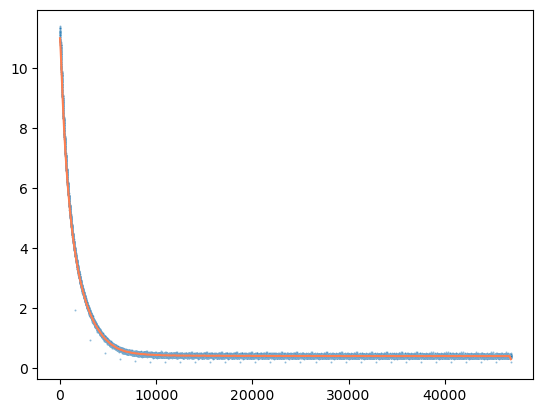

In [113]:
antipode.plotting.plot_loss(losses)

In [94]:
pyro.param('total_counts')

tensor([1.1993, 0.4661, 0.8612, 0.0957, 1.3703, 0.2618, 1.2160, 0.8859, 0.3207,
        0.1361, 0.8703, 1.8155, 2.4656, 1.8166, 1.9935, 1.8489, 0.0956, 0.5822,
        0.0956, 0.3241, 0.2888, 1.8485, 0.6264, 0.5560, 0.1491, 2.1502, 0.3943,
        0.2013, 1.1757, 1.0121, 0.0957, 1.7309, 0.2417, 0.6439, 0.1439, 1.2636,
        0.1869, 0.2638, 0.3895, 0.2859, 0.8106, 0.1553, 0.9369, 0.8186, 0.0957,
        1.6691, 0.5575, 0.6722, 0.3780, 0.2745, 0.8371, 0.0956, 0.0956, 0.9666,
        0.1737, 1.0416, 2.0883, 0.1670, 0.7200, 2.0273, 0.3107, 0.3790, 0.7735,
        0.7445, 0.1811, 1.9376, 1.2497, 0.8518, 0.1385, 0.4699, 0.2465, 0.4613,
        1.1994, 0.5369, 0.2066, 0.3207, 0.2224, 1.0897, 0.6653, 0.0956, 1.7512,
        1.0138, 0.5847, 0.5204, 0.4292, 0.8712, 1.1444, 0.3801, 0.1906, 0.3924,
        0.0957, 0.7110, 0.2026, 0.6671, 0.7648, 0.2026, 1.4835, 0.2511, 1.8789,
        0.9591, 0.2242, 0.8375, 0.1551, 0.1785, 0.1908, 0.3843, 0.9600, 0.0957,
        2.1595, 0.5038, 0.3282, 0.3035, 

In [116]:
toy_model.eval()
latents=[]
clusters=[]
for j in range(0, n_datapoints, batch_size):
    batch = data[j:j+batch_size].to(device)
    latent=toy_model.encoder(batch)
    latents.append(latent[0].cpu().detach().numpy())
    component=toy_model.classifier(latent[0])
    clusters.append(component.cpu().detach().numpy())


In [117]:
adata.obsm['rec_latents']=np.concatenate(latents,axis=0)
adata.obs['rec_clusters']=np.concatenate(clusters,axis=0).argmax(-1)
adata.obs['rec_clusters']=adata.obs['rec_clusters'].astype(str)

In [118]:
out_locs = pyro.param('locs').detach().cpu().numpy()
out_transform_matrix = pyro.param('transform_matrix').detach().cpu().numpy()
out_intercept = pyro.param('intercept').detach().cpu().numpy()
out_total_counts = pyro.param('total_counts').detach().cpu().numpy()

# Compute the learned cluster means
learned_means = out_locs @ out_transform_matrix + out_intercept #+ (out_total_counts**2/2)
learned_means_clusters=[str(x) for x in range(learned_means.shape[0])]
#actual_means = true_params['locs'] @ true_params['transform_matrix'] + true_params['intercept']
actual_means = antipode.model_functions.group_aggr_anndata(adata,['rec_clusters'],normalize=True)
learned_means=learned_means[pd.Series(learned_means_clusters).isin(actual_means[1]['rec_clusters']),:]
actual_means=np.log(actual_means[0]+actual_means[0][actual_means[0]>0].min()*0.9)

100%|██████████| 15/15 [00:00<00:00, 246.69it/s]


In [119]:
zdw_grads=np.absolute(np.stack(grads['transform_matrix'])).mean(0)

Text(0, 0.5, 'abs gradient')

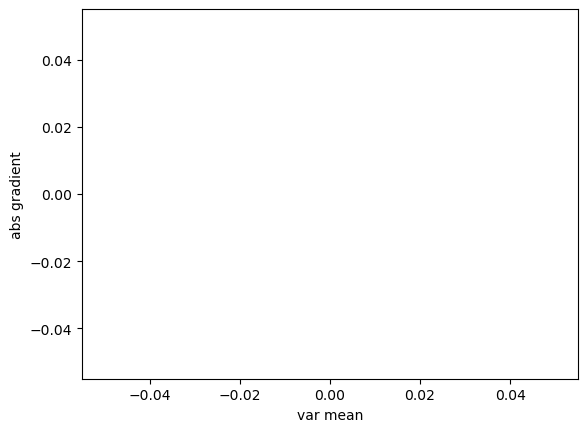

In [120]:
seaborn.scatterplot(x=actual_means.mean(0),y=np.log(zdw_grads.mean(0)),s=1)
plt.xlabel('var mean')
plt.ylabel('abs gradient')

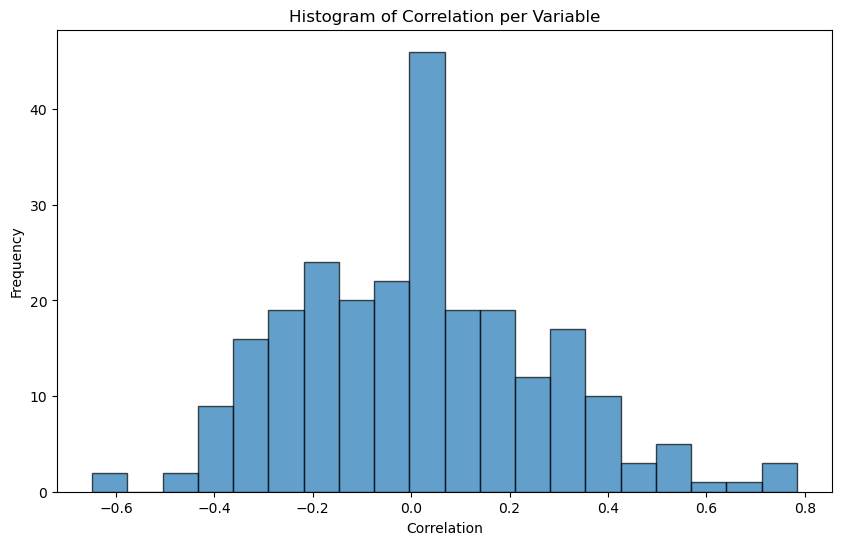

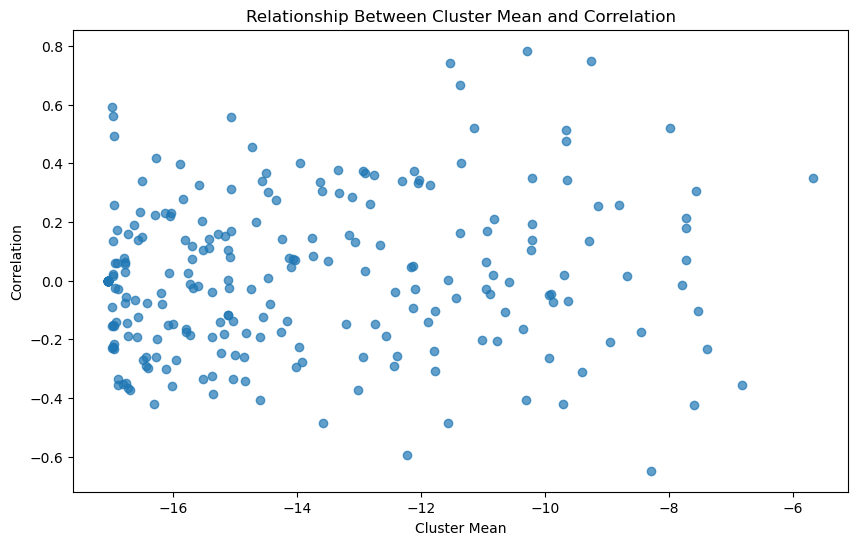

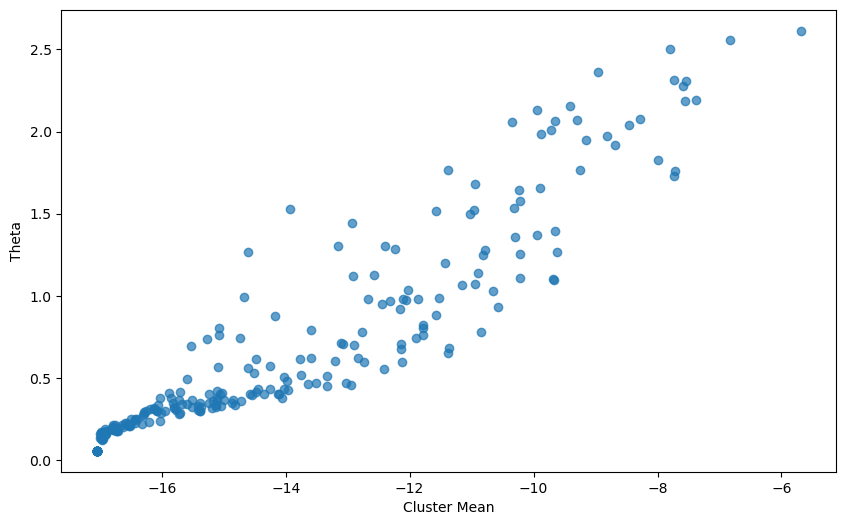

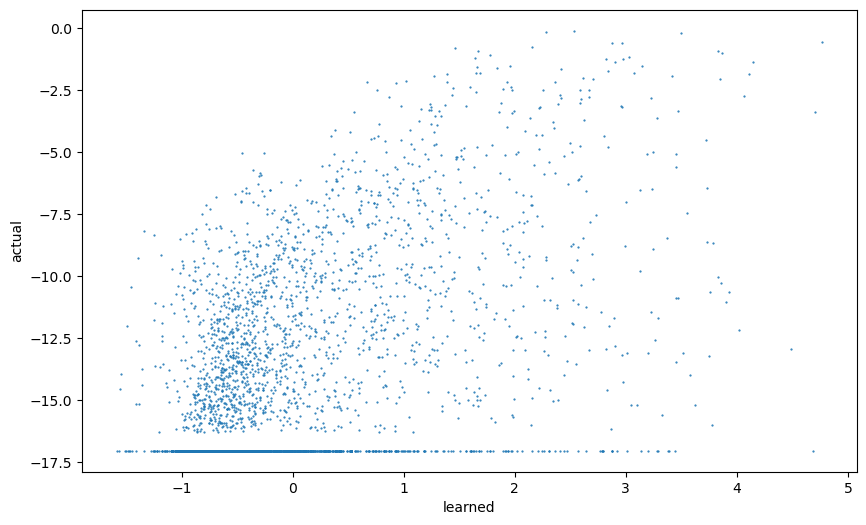

In [121]:
correlations = []
for i in range(toy_model.n_var):
    corr = np.corrcoef(actual_means[:, i], learned_means[:, i])[0, 1]
    correlations.append(corr)

# Plot a histogram of the correlations
plt.figure(figsize=(10, 6))
plt.hist(correlations, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Histogram of Correlation per Variable')
plt.show()

# Plot the relationship between the correlation and the cluster mean
plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), correlations, alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Correlation')
plt.title('Relationship Between Cluster Mean and Correlation')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), pyro.param('total_counts').cpu().detach().numpy(), alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Theta')
plt.show()


plt.figure(figsize=(10, 6))
plt.scatter(learned_means.flatten(),actual_means.flatten(),s=0.3)
plt.ylabel('actual')
plt.xlabel('learned')
plt.show()


In [122]:
adata.obsm['rec_mde']=scvi.model.utils.mde(adata.obsm['rec_latents'],init='random')
adata.obsm['true_mde']=scvi.model.utils.mde(adata.obsm['true_latents'],init='random')

INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


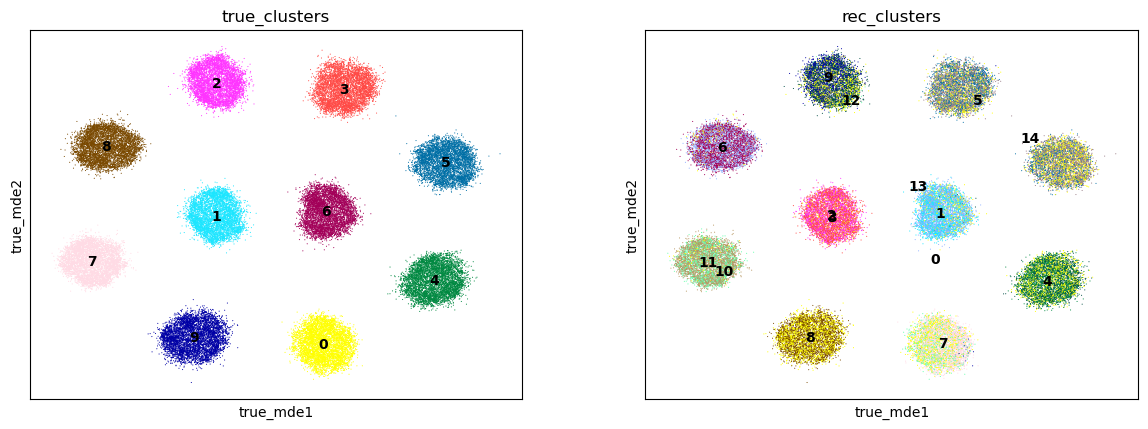

In [123]:
sc.pl.embedding(
    adata,
    basis='true_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)


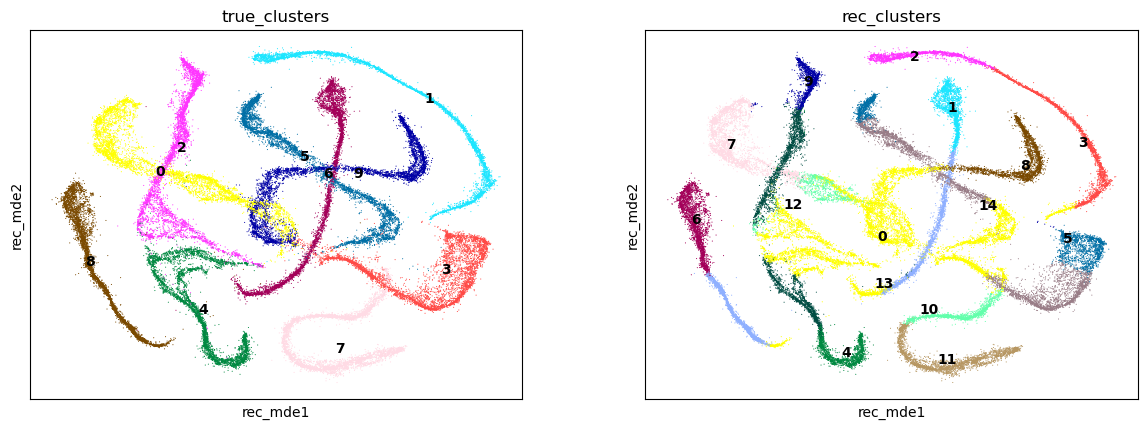

In [124]:
sc.pl.embedding(
    adata,
    basis='rec_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

In [38]:
d=ZeroInflatedLogNormal(loc=torch.tensor(3.1330), scale=torch.tensor(10.),cutoff=torch.tensor(0.))

In [3]:
total_counts=1*torch.ones(1)
mus=torch.linspace(-10., 10.,500).unsqueeze(0)


Text(0.5, 1.0, 'Negative Binomial')

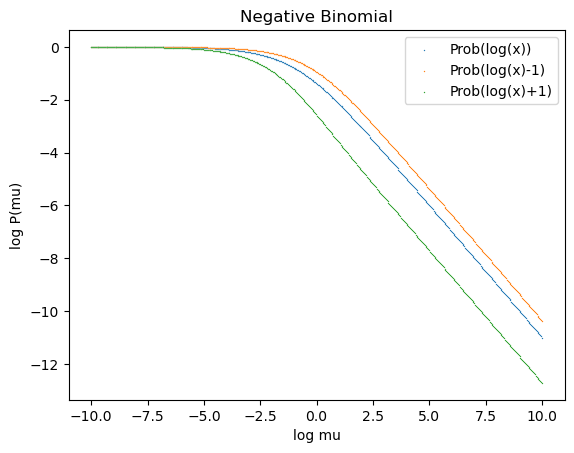

In [4]:
log_probs=dist.NegativeBinomial(total_count=total_counts,logits=mus-total_counts.log(),validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=1,label='Prob(log(x))')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=1,label='Prob(log(x)-1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=1,label='Prob(log(x)+1)')
plt.xlabel('log mu')
plt.ylabel('log P(mu)')
plt.title('Negative Binomial')

Text(0, 0.5, 'log prob')

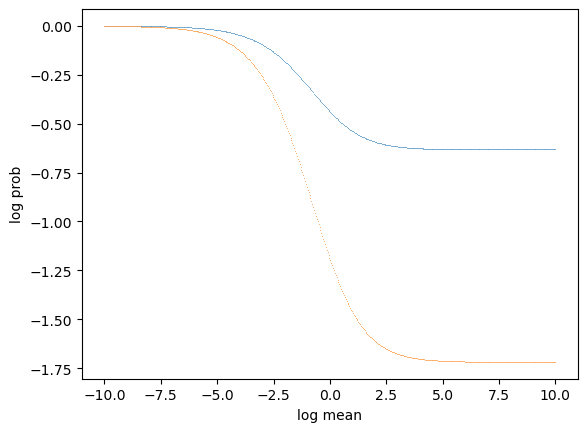

In [34]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)
plt.xlabel('log mean')
plt.ylabel('log prob')

Text(0.5, 1.0, 'Negative Binomial')

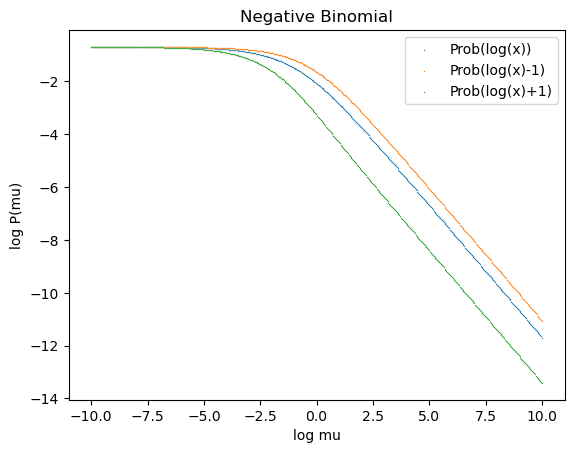

In [5]:
log_probs=dist.ZeroInflatedNegativeBinomial(total_count=total_counts,logits=mus-total_counts.log(),gate=0.5*mus.new_ones(mus.shape),validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=1,label='Prob(log(x))')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=1,label='Prob(log(x)-1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=1,label='Prob(log(x)+1)')
plt.xlabel('log mu')
plt.ylabel('log P(mu)')
plt.title('Negative Binomial')

Text(0, 0.5, 'log prob')

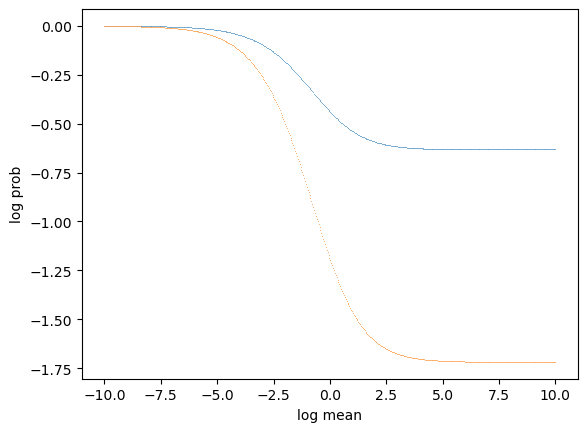

In [6]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)
plt.xlabel('log mean')
plt.ylabel('log prob')

In [35]:
total_counts=1*torch.ones(1)
mus=torch.linspace(-30., 30.,1000).unsqueeze(0)
log_probs=dist.NegativeBinomial(total_count=total_counts,probs=total_counts/(mus.exp()+total_counts),validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1],dim=0).exp())

<Axes: >

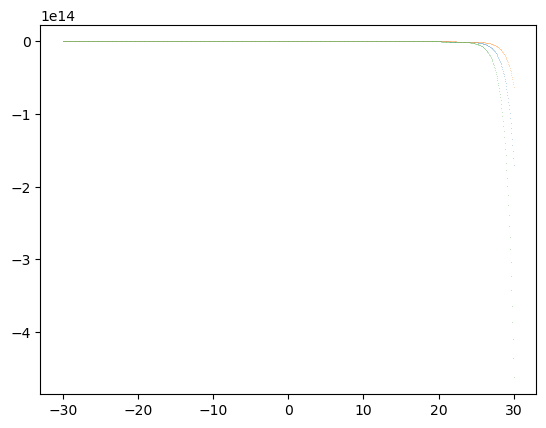

In [36]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.2)

<Axes: >

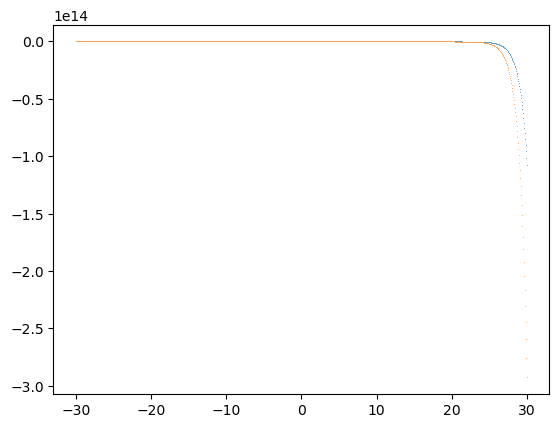

In [37]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


In [38]:
def unnormalized_NB(total_counts,logits,value):
    return(total_counts * F.logsigmoid(
        -logits
    ) + value * F.logsigmoid(logits))
    
log_probs=unnormalized_NB(total_counts,mus-total_counts.log(),torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0).exp())

In [39]:
def unnormalized_NB(total_counts,logits,value):
    return(logits-total_counts.log() - (logits)-value.log())
    
log_probs=unnormalized_NB(total_counts,mus-total_counts.log(),torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0).exp())

<Axes: >

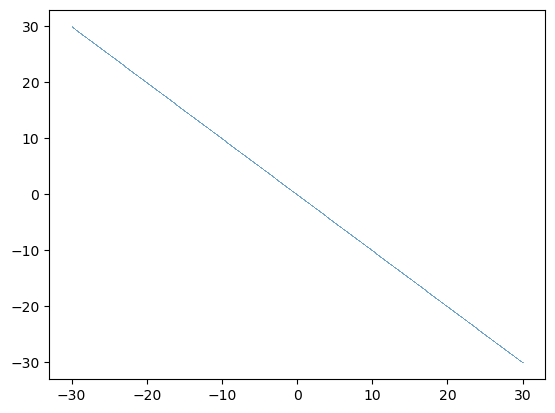

In [40]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)


<Axes: >

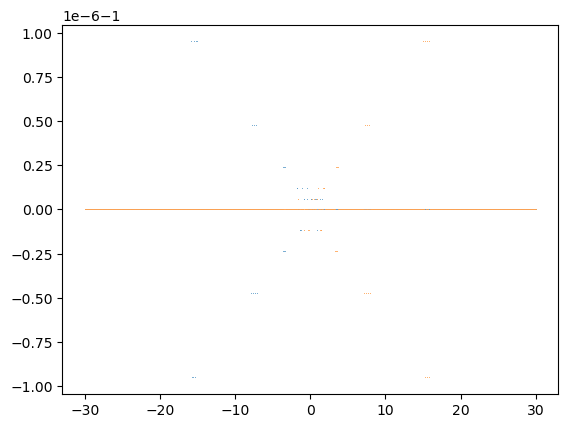

In [41]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


In [42]:
log_probs=dist.LogNormal(loc=mus,scale=total_counts,validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0).exp())

Text(0.5, 1.0, 'LogNormal')

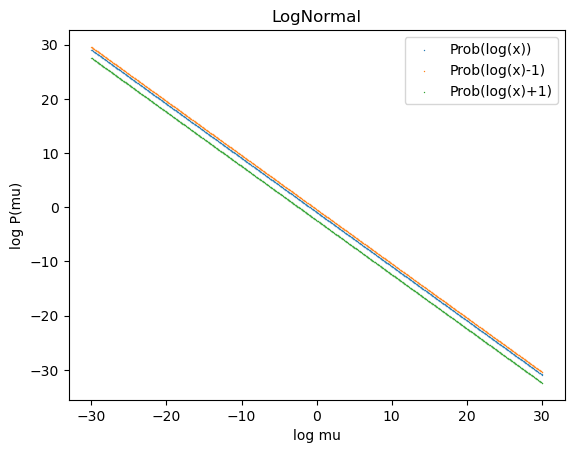

In [43]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=1,label='Prob(log(x))')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=1,label='Prob(log(x)-1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=1,label='Prob(log(x)+1)')
plt.xlabel('log mu')
plt.ylabel('log P(mu)')
plt.title('LogNormal')

<Axes: >

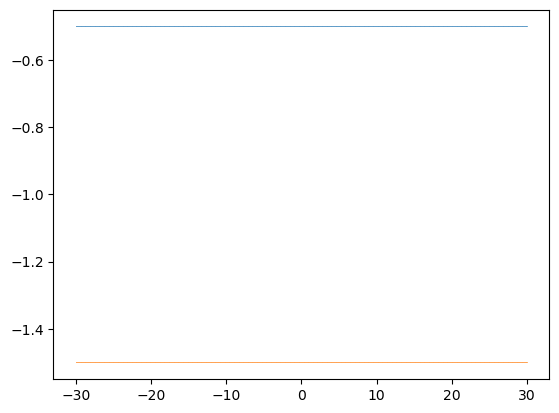

In [44]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


In [45]:
log_probs=ZeroInflatedLogNormal(loc=mus,scale=total_counts,cutoff=torch.zeros(1),validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0).exp())

NameError: name 'ZeroInflatedLogNormal' is not defined

<Axes: >

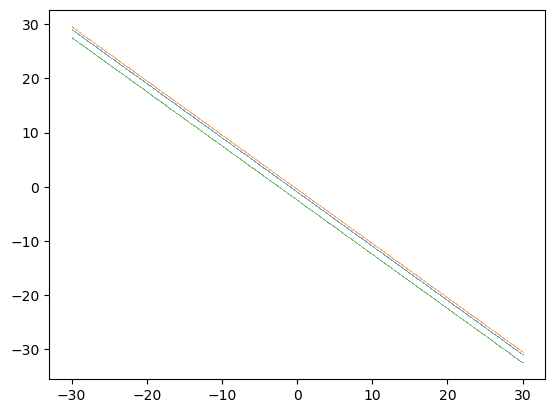

In [46]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)

<Axes: >

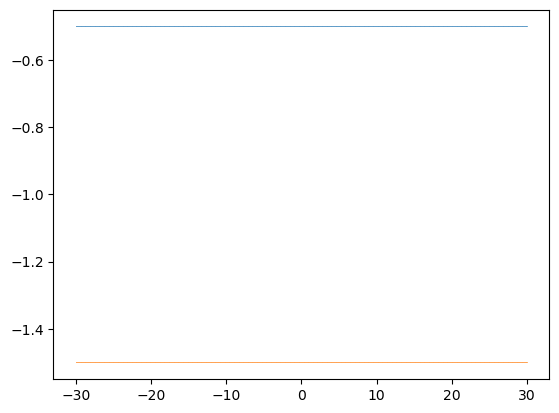

In [47]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


In [48]:
log_probs=dist.RelaxedBernoulli(temperature=0.0001*torch.ones(1),logits=mus,validate_args=False).log_prob(torch.sigmoid(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0)))

<Axes: >

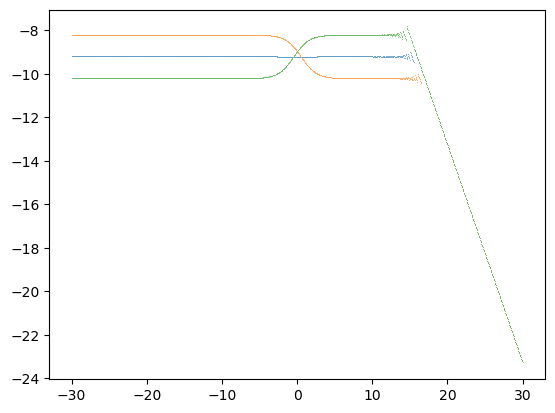

In [49]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)

<Axes: >

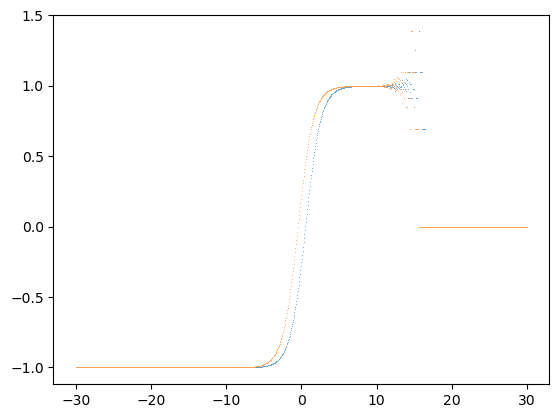

In [50]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)

In [51]:
log_probs=dist.Bernoulli(logits=mus,validate_args=False).log_prob(torch.sigmoid(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0)))

<Axes: >

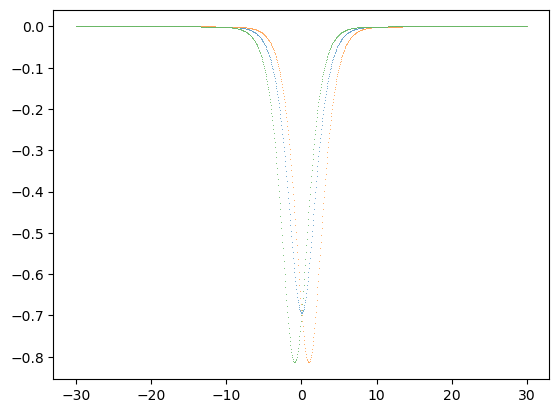

In [52]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)

<Axes: >

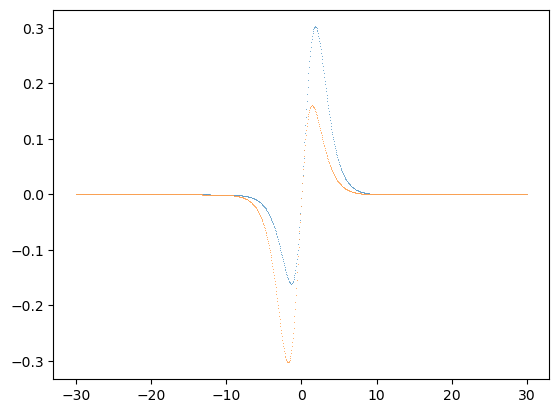

In [53]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)

In [54]:
log_probs=dist.Poisson(rate=mus.exp(),validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0).exp())

<Axes: >

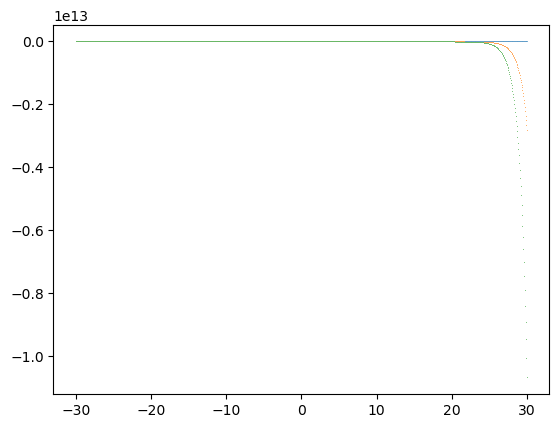

In [55]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)

<Axes: >

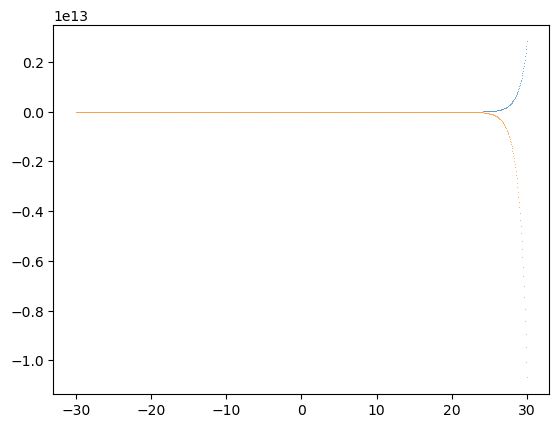

In [56]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)

<Axes: >

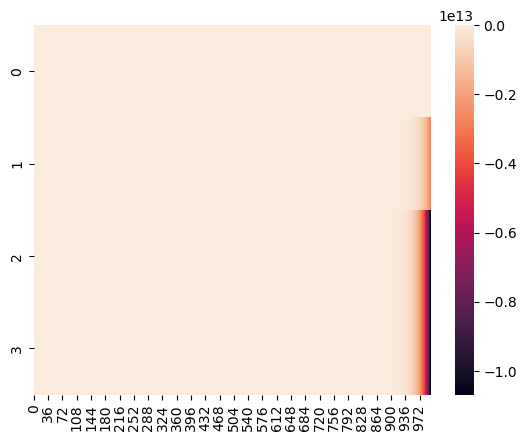

In [57]:
seaborn.heatmap(log_probs.numpy())

<Axes: >

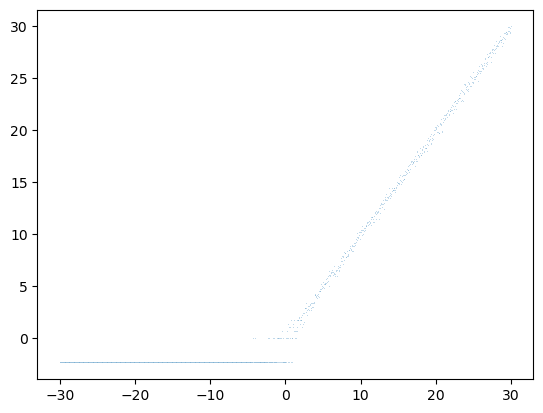

In [58]:
total_counts=10*torch.ones(1)
mus=torch.linspace(-30., 30.,1000).unsqueeze(0)
nb_outs=dist.NegativeBinomial(total_count=total_counts,logits=mus-total_counts.log(),validate_args=False).sample()
seaborn.scatterplot(x=mus.numpy().flatten(),y=np.log(nb_outs.numpy().flatten()+1e-1),s=0.2)

<Axes: >

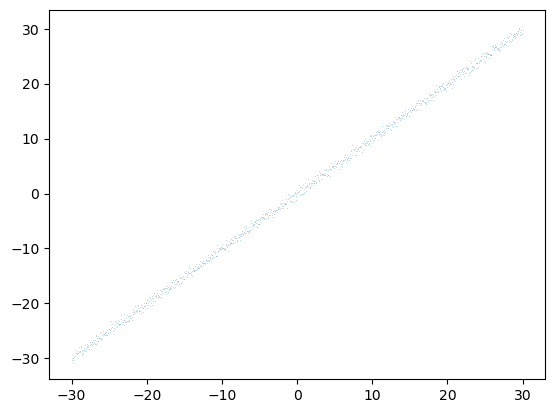

In [59]:
ln_outs=dist.LogNormal(loc=mus,scale=5/total_counts,validate_args=False).sample()
seaborn.scatterplot(x=mus.numpy().flatten(),y=np.log(ln_outs.numpy().flatten()+1e-15),s=0.2)

<Axes: >

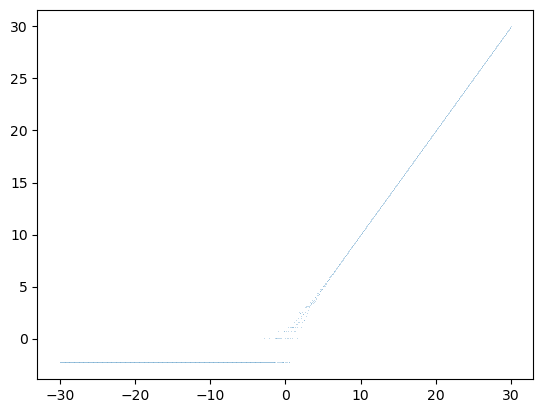

In [61]:
ln_outs=dist.Poisson(rate=mus.exp(),validate_args=False).sample()
seaborn.scatterplot(x=mus.numpy().flatten(),y=np.log(ln_outs.numpy().flatten()+1e-1),s=0.2)